In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Shared style constants (poster quality) ────────────────────────────────────
TITLE_SIZE  = 14
LABEL_SIZE  = 12
TICK_SIZE   = 10
ANNOT_SIZE  = 9
DPI         = 300

# ── Load GBD ──────────────────────────────────────────────────────────────────
gbd = pd.read_csv(
    "../data/raw/IHME-GBD_2023_DATA-54ccbeed-1/IHME-GBD_2023_DATA-54ccbeed-1.csv"
)

# Load World Bank country name list (used as national-level filter)
gdp_raw = pd.read_csv(
    "../data/raw/API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_121708/API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_121708.csv",
    skiprows=4
)
wb_names = set(gdp_raw["Country Name"].dropna())

# Filter out regional aggregates
exclude = ["WB", "WHO", "Global", "World", "Region", "SDI", "Income", "Asia",
           "Africa", "Europe", "America", "Latin", "Oceania", "Caribbean", "Saharan"]
mask = ~gbd["location_name"].str.contains("|".join(exclude), na=False)

# Filter to 2021, Both sexes, national-level only
gbd_2021 = gbd[
    mask &
    (gbd["year"] == 2021) &
    (gbd["sex_name"] == "Both") &
    (gbd["location_name"].isin(wb_names))
].copy()

print(f"National-level countries (2021, Both sexes): {gbd_2021['location_name'].nunique()}")
gbd_2021[["location_name", "val", "upper", "lower"]].describe()

National-level countries (2021, Both sexes): 170


,val,upper,lower
count,172.000000,172.000000,172.000000
mean,18.570489,26.901468,12.279674
std,13.792022,19.766854,9.192541
min,3.971007,5.733495,2.535333
25%,8.297203,11.892374,5.566937
50%,14.667368,21.107136,9.774330
75%,23.401510,34.307266,15.446955
max,77.167718,107.972668,52.212351


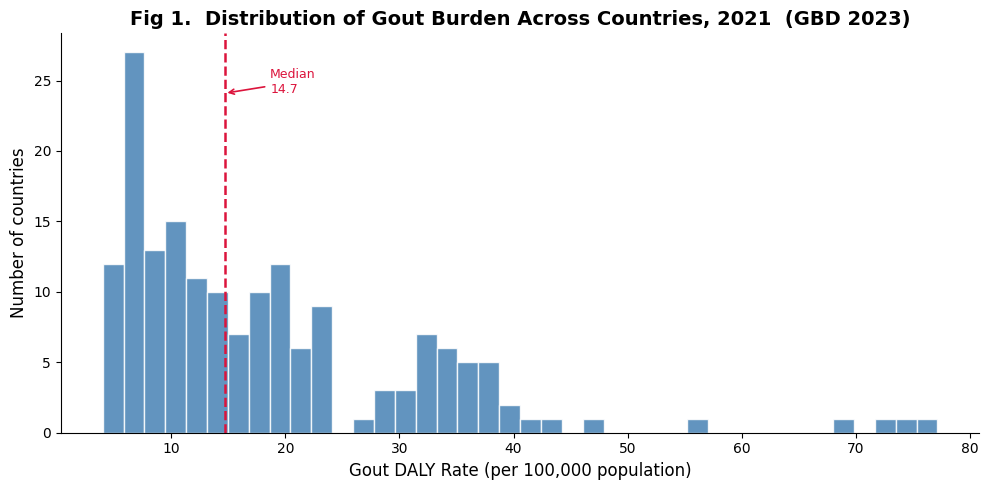

Saved: figures/fig1_histogram.png


In [2]:
# ── Fig 1: Histogram of DALY rate distribution ────────────────────────────────
median_val = gbd_2021["val"].median()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(gbd_2021["val"], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(median_val, color="crimson", linewidth=1.8, linestyle="--",
           label=f"Median = {median_val:.1f}")
ax.annotate(f"Median\n{median_val:.1f}",
            xy=(median_val, ax.get_ylim()[1] * 0.85),
            xytext=(median_val + 4, ax.get_ylim()[1] * 0.85),
            fontsize=ANNOT_SIZE, color="crimson",
            arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2))

ax.set_xlabel("Gout DALY Rate (per 100,000 population)", fontsize=LABEL_SIZE)
ax.set_ylabel("Number of countries", fontsize=LABEL_SIZE)
ax.set_title("Fig 1.  Distribution of Gout Burden Across Countries, 2021  (GBD 2023)",
             fontsize=TITLE_SIZE, fontweight="bold")
ax.tick_params(labelsize=TICK_SIZE)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../figures/fig1_histogram.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved: figures/fig1_histogram.png")

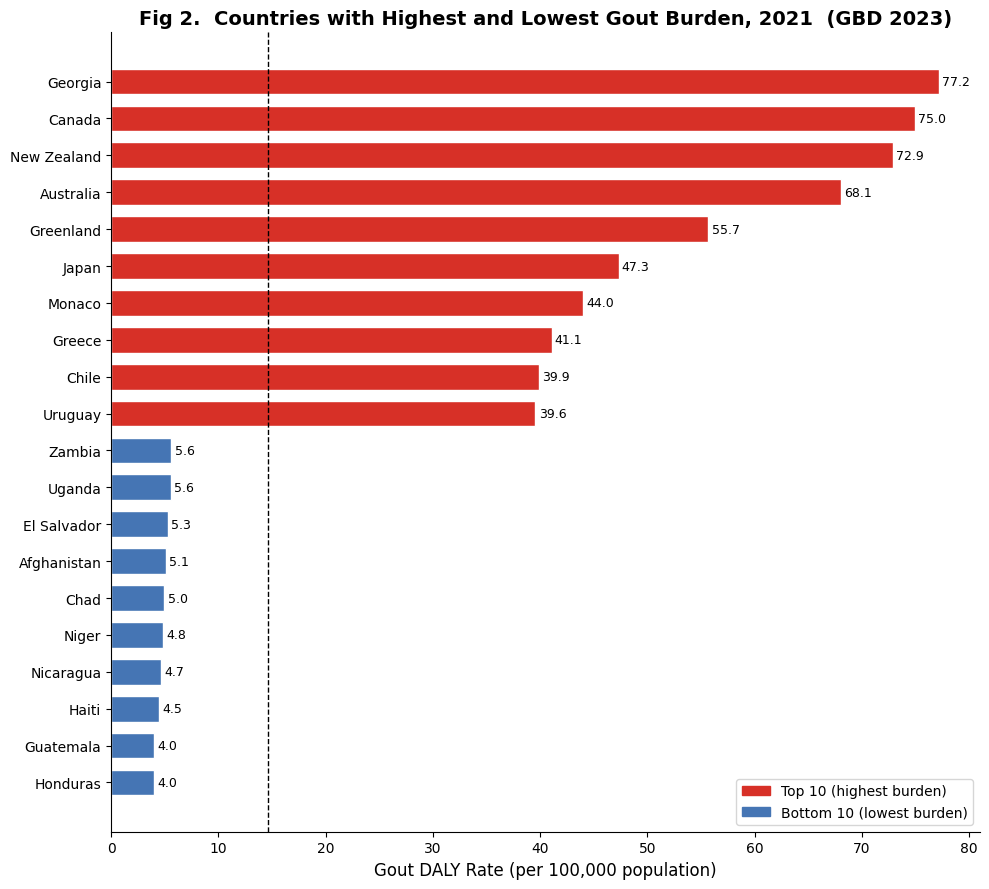

Saved: figures/fig2_ranking.png


In [3]:
# ── Fig 2: Top 10 / Bottom 10 country ranking ─────────────────────────────────
gbd_sorted = gbd_2021.sort_values("val", ascending=False)
top10 = gbd_sorted.head(10)
bot10 = gbd_sorted.tail(10)

# Combine and sort ascending so highest appears at top of barh
ranking = pd.concat([bot10, top10]).sort_values("val", ascending=True)

colors = ["#4575b4"] * 10 + ["#d73027"] * 10  # blue = bottom, red = top

fig, ax = plt.subplots(figsize=(10, 9))

bars = ax.barh(ranking["location_name"], ranking["val"],
               color=colors, edgecolor="white", height=0.7)

# Add value labels at end of each bar
for bar, val in zip(bars, ranking["val"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=ANNOT_SIZE)

median_val = gbd_2021["val"].median()
ax.axvline(median_val, color="black", linestyle="--", linewidth=1,
           label=f"Global median = {median_val:.1f}")

# Legend
red_patch  = mpatches.Patch(color="#d73027", label="Top 10 (highest burden)")
blue_patch = mpatches.Patch(color="#4575b4", label="Bottom 10 (lowest burden)")
ax.legend(handles=[red_patch, blue_patch], fontsize=TICK_SIZE, loc="lower right")

ax.set_xlabel("Gout DALY Rate (per 100,000 population)", fontsize=LABEL_SIZE)
ax.set_title("Fig 2.  Countries with Highest and Lowest Gout Burden, 2021  (GBD 2023)",
             fontsize=TITLE_SIZE, fontweight="bold")
ax.tick_params(labelsize=TICK_SIZE)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../figures/fig2_ranking.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved: figures/fig2_ranking.png")

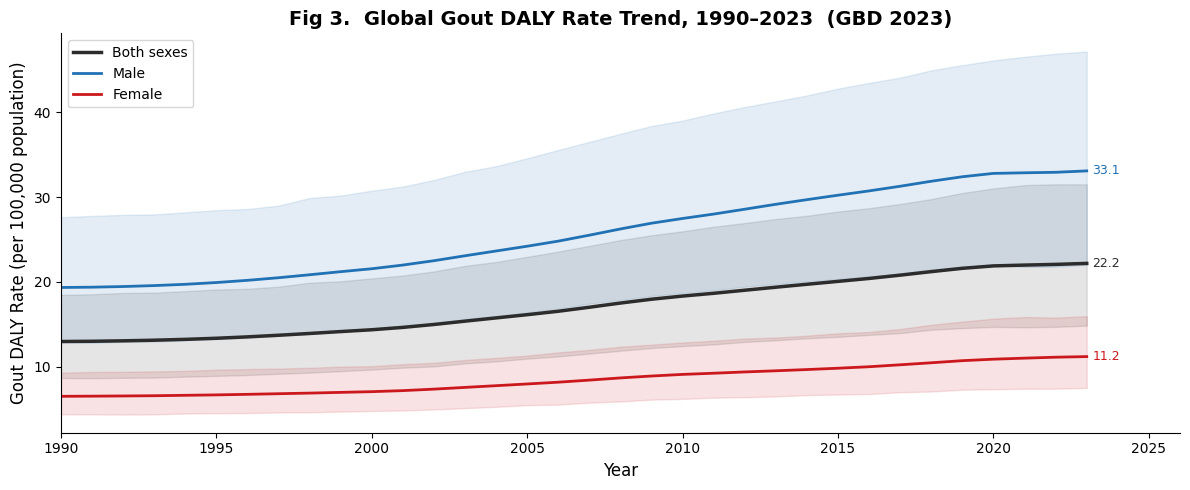

Saved: figures/fig3_time_trend.png


In [4]:
# ── Fig 3: Global time trend 1990-2023 with 95% CI shading ───────────────────
gbd_global = gbd[
    (gbd["location_name"] == "Global") &
    (gbd["sex_name"].isin(["Male", "Female", "Both"]))
].copy()

sex_styles = {
    "Both":   {"color": "#2c2c2c", "label": "Both sexes",  "lw": 2.5},
    "Male":   {"color": "#2171b5", "label": "Male",        "lw": 2.0},
    "Female": {"color": "#cb181d", "label": "Female",      "lw": 2.0},
}

fig, ax = plt.subplots(figsize=(12, 5))

for sex, style in sex_styles.items():
    df = gbd_global[gbd_global["sex_name"] == sex].sort_values("year")
    ax.plot(df["year"], df["val"],
            color=style["color"], linewidth=style["lw"], label=style["label"])
    # 95% CI shading
    ax.fill_between(df["year"], df["lower"], df["upper"],
                    alpha=0.12, color=style["color"])
    # Annotate 2023 endpoint
    last = df[df["year"] == df["year"].max()].iloc[0]
    ax.annotate(f"{last['val']:.1f}",
                xy=(last["year"], last["val"]),
                xytext=(4, 0), textcoords="offset points",
                fontsize=ANNOT_SIZE, color=style["color"], va="center")

ax.set_xlabel("Year", fontsize=LABEL_SIZE)
ax.set_ylabel("Gout DALY Rate (per 100,000 population)", fontsize=LABEL_SIZE)
ax.set_title("Fig 3.  Global Gout DALY Rate Trend, 1990\u20132023  (GBD 2023)",
             fontsize=TITLE_SIZE, fontweight="bold")
ax.legend(fontsize=TICK_SIZE)
ax.tick_params(labelsize=TICK_SIZE)
ax.set_xlim(1990, 2026)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../figures/fig3_time_trend.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("Saved: figures/fig3_time_trend.png")